## Color Quantization with k‑Means (scikit‑learn)


### 🔍 해석

### 🔹 **Color Quantization**

- **의미**: 색상 양자화
- **설명**: 원본 이미지가 수천~수만 개의 서로 다른 색상으로 구성되어 있을 수 있는데, 이 색상의 **수를 제한된 개수(예: 8개, 16개 등)**로 줄이는 작업입니다.
    - 목적: 이미지 크기를 줄이거나, 주요 색상만 추출해 시각화 혹은 데이터 전처리 등으로 활용하기 위해 사용됩니다.
    - 예시: 원래 1,000개의 서로 다른 색상을 16개의 대표 색상으로 줄임

### 🔹 **k-Means**

- **의미**: 군집화(clustering) 알고리즘
- **설명**: 데이터를 `k`개의 중심(centroid) 주변으로 묶는 알고리즘으로, 색상 데이터를 벡터(예: RGB 값)로 보고 비슷한 색들을 군집화할 수 있습니다.
    - 이미지의 각 픽셀을 RGB 공간의 점으로 생각하고, 이 점들을 `k`개의 클러스터로 분할합니다.
    - 각 클러스터의 중심값이 **대표 색상**이 됩니다.

### 🔹 **(scikit-learn)**

- **의미**: Python의 머신러닝 라이브러리
- **설명**: `k-Means` 알고리즘을 포함하고 있어, 이를 사용해 색상 양자화를 구현할 수 있다는 의미입니다.

Loaded image: (200, 150, 3)


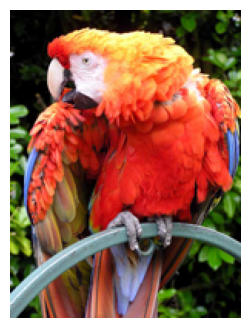

In [9]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 이미지 파일을 불러와 RGB 형태로 변환하고,
# NumPy 배열로 변환하여 시각화한 뒤 이미지의 크기(shape)를 출력하는 기초 전처리 단계임.
# Color Quantization, k-means clustering 등 후속 처리를 위한 입력 데이터를 준비하는 목적의 코드임.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 이미지 파일 경로 설정 및 파일 로딩
# 2단계: 이미지를 RGB 형식으로 변환
# 3단계: 이미지를 NumPy 배열로 변환하여 데이터화
# 4단계: 이미지 시각화 (크기 조정 + 축 제거)
# 5단계: 이미지 배열의 shape(높이, 너비, 채널 수) 출력
# ------------------------------------------------------------

from PIL import Image  
# 이미지 로딩 및 포맷 변환을 위한 Python Imaging Library 모듈 임포트

import numpy as np  
# 이미지 데이터를 배열 형태로 처리하기 위한 NumPy 모듈 임포트

import matplotlib.pyplot as plt  
# 이미지 시각화를 위한 matplotlib 모듈 임포트

# ------------------------------------------------------------
# [1단계] 이미지 파일 경로 설정 및 로딩
# ------------------------------------------------------------

img_path = 'input.jpg'  
# 불러올 이미지의 경로를 문자열로 지정함
# 사용자가 직접 업로드한 파일을 지정하거나 외부 이미지 경로를 입력해야 함

img = Image.open(img_path).convert('RGB')  
# 지정된 경로의 이미지를 열고(RGB 이외의 포맷일 수 있으므로)
# RGB 형식으로 강제 변환하여 일관된 색상 채널 구조로 변환함
# 이후 처리에서 RGB 채널 값(R, G, B)을 벡터로 활용 가능하게 준비함

# ------------------------------------------------------------
# [2단계] NumPy 배열로 변환 및 시각화
# ------------------------------------------------------------

img_np = np.array(img)  
# PIL 이미지 객체를 NumPy 배열로 변환함
# 각 픽셀은 (높이, 너비, 채널 수=3)의 배열로 표현되며
# 이후 k-means clustering 등에서 각 픽셀을 벡터로 간주하여 처리 가능함

plt.figure(figsize=(4,4))  
# 이미지 출력 시 그림 크기를 4x4인치로 설정하여 적절한 크기로 표시함

plt.imshow(img_np)  
# NumPy 배열 형식의 이미지를 시각화하여 화면에 출력함
# RGB 색상 공간을 기반으로 이미지가 표현됨

plt.axis('off')  
# 시각화된 이미지의 x, y 축 숫자와 틀을 제거하여 순수한 이미지 형태로 보여줌
# 이미지 분석에서 시각적 간결성을 확보하는 데 사용됨

# ------------------------------------------------------------
# [3단계] 이미지 shape 출력
# ------------------------------------------------------------

print('Loaded image:', img_np.shape)  
# 변환된 이미지 배열의 크기를 출력함
# 출력 형식은 (높이, 너비, 채널 수)이며, CNN, k-means 등 후속 모델 입력 전 확인 단계로 활용됨


In [10]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 단계는 RGB 이미지 데이터를 k-means 클러스터링 알고리즘에 입력하기 위해
# 3차원 이미지 배열을 2차원 형태(N, 3)의 데이터 행렬로 변환하고, 픽셀 값을 정규화하는 과정임.
# 이 변환은 각 픽셀을 하나의 3차원 벡터(R, G, B)로 보고 군집화하는 전처리 단계임.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 이미지의 세부 크기(height, width, 채널 수)를 분해하여 변수로 저장
# 2단계: 이미지 배열을 (H×W, 3)의 형태로 변형 (각 행은 한 픽셀의 RGB값)
# 3단계: RGB 값을 0~1 범위로 정규화하여 k-means 입력에 적합한 값으로 변환
# ------------------------------------------------------------

h, w, _ = img_np.shape  
# NumPy 배열로 변환된 이미지의 높이(h), 너비(w), 채널 수(_)를 변수에 할당함
# 채널 수는 사용하지 않기 때문에 밑줄(_)로 무시 처리함
# 이후 복원 또는 색상 재구성을 위해 원래 이미지의 크기를 보존할 필요가 있음

X = img_np.reshape(-1, 3).astype(np.float32) / 255.0  
# 이미지 배열을 (H×W, 3)의 2차원 배열로 재구성함
# 각 행은 하나의 픽셀을 의미하며, RGB의 3채널 값으로 구성됨
# float32 타입으로 변환 후 255로 나누어 0~1 사이의 실수 값으로 정규화함
# k-means는 유클리디안 거리 기반 알고리즘이므로 스케일 정규화가 매우 중요함
# 정규화를 통해 학습 안정성과 수렴 속도를 높이는 효과를 기대할 수 있음


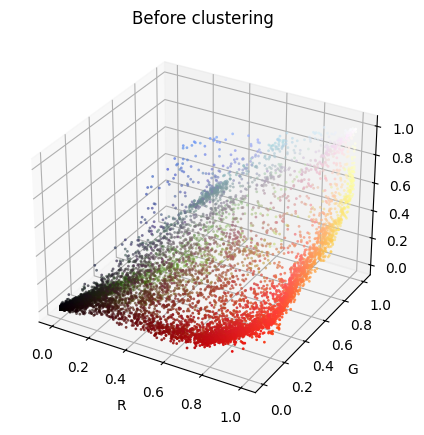

In [11]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 단계는 RGB 이미지 데이터를 3차원 색상 공간(R, G, B)에서 시각화하는 과정임.
# 클러스터링 이전의 색상 분포가 어떻게 구성되어 있는지를 3D scatter plot으로 시각적으로 표현하여
# 데이터가 색 공간상에서 어떻게 분포되어 있는지 직관적으로 확인하는 데 목적이 있음.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 전체 픽셀 중 일부를 무작위로 샘플링하여 시각화에 사용할 데이터 추출
# 2단계: 3차원 RGB 색상 공간에 점들을 시각화 (R, G, B 축 기준)
# 3단계: 색상을 그대로 유지한 상태에서 시각화하여 분포 특성을 시각적으로 파악
# ------------------------------------------------------------

n_sample = min(8000, len(X))  
# 샘플링할 픽셀 수를 설정함 (최대 8000개 또는 전체 픽셀 수 중 작은 값 선택)
# 시각화 성능과 해석 가능성을 고려해 너무 많은 점은 제외함

idx = np.random.choice(len(X), n_sample, replace=False)  
# 전체 픽셀 인덱스 중에서 중복 없이 무작위로 n_sample개를 선택함
# 무작위 샘플링을 통해 전체 색상 분포를 대표할 수 있는 점들을 추출함

Xs = X[idx]  
# 위에서 선택한 인덱스를 기준으로 RGB 샘플을 추출하여 Xs에 저장함
# Xs는 (n_sample, 3) 크기의 배열로, 시각화에 사용될 RGB 벡터 집합임

fig = plt.figure(figsize=(12, 5))  
# 시각화를 위한 새로운 figure 객체 생성
# 가로 12인치, 세로 5인치 크기로 출력 크기를 설정함

ax1 = fig.add_subplot(1, 1, 1, projection='3d')  
# 1행 1열 중 첫 번째 subplot을 3D 축으로 추가함
# RGB 공간은 3차원이므로 3D scatter plot으로 시각화할 필요가 있음

ax1.scatter(Xs[:, 0], Xs[:, 1], Xs[:, 2], c=Xs, s=4, edgecolor='none')  
# 샘플 픽셀들의 R, G, B 값을 x, y, z 좌표로 사용하여 산점도 생성
# 각 점의 색상은 해당 픽셀의 실제 RGB 값(Xs)으로 설정
# 점 크기는 4로 작게 설정하고, 테두리는 없앰(edgecolor='none')
# 시각적으로 RGB 공간에서 색들이 어떻게 분포하는지 직관적으로 확인 가능함

ax1.set_title('Before clustering')  
# 그래프 제목을 설정하여 클러스터링 이전 상태임을 명시함

ax1.set_xlabel('R')  
# x축 라벨을 'R'로 설정하여 빨강 채널임을 나타냄

ax1.set_ylabel('G')  
# y축 라벨을 'G'로 설정하여 초록 채널임을 나타냄

ax1.set_zlabel('B')  
# z축 라벨을 'B'로 설정하여 파랑 채널임을 나타냄


In [12]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 단계는 RGB 색상 벡터 데이터(X)에 대해 k-Means 클러스터링을 적용하여
# 이미지의 색상들을 k개의 대표 색상으로 압축하는 과정임.
# 결과적으로 각 픽셀은 클러스터 중심 중 하나에 속하게 되며,
# 이 중심값이 색상 팔레트로 활용됨.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 사용할 대표 색상의 개수 k를 지정 (색상 팔레트 크기)
# 2단계: k-Means 클러스터링 모델 생성 및 초기화 방식 설정
# 3단계: 주어진 RGB 데이터 X에 대해 클러스터링 수행 및 각 픽셀의 클러스터 할당
# 4단계: 각 클러스터의 중심 좌표(대표 색상) 추출
# 5단계: 클러스터링의 적합도 지표(inertia)를 출력하여 수렴 정도 확인
# ------------------------------------------------------------

from sklearn.cluster import KMeans  
# k-Means 클러스터링 알고리즘을 제공하는 scikit-learn의 모듈 임포트

k = 16  
# 사용할 대표 색상의 개수를 16개로 설정함
# 이는 최종 이미지에 포함될 고유 색상의 개수를 의미하며, 압축 비율과 시각적 품질에 영향을 줌

kmeans = KMeans(n_clusters=k, init='k-means++')  
# k-Means 클러스터링 모델 객체 생성
# 클러스터 수는 k로 설정하고, 초기 중심점은 'k-means++' 방식으로 똑똑하게 초기화함
# 'k-means++'는 클러스터링의 수렴 속도와 품질을 높이기 위한 표준 기법임

labels = kmeans.fit_predict(X)  
# RGB 벡터 X에 대해 클러스터링을 수행하고, 각 픽셀이 어떤 클러스터에 속하는지 예측함
# 결과는 `labels` 배열로 반환되며, 길이는 X와 동일하고 값은 0부터 k-1까지의 클러스터 번호임
# 이 과정에서 내부적으로 반복적 중심 업데이트 및 수렴 확인이 이루어짐

palette = kmeans.cluster_centers_  
# 학습된 k개의 클러스터 중심(RGB 벡터)을 추출하여 palette 변수에 저장함
# 이 중심값들이 k개의 대표 색상으로 간주되며, 이후 이미지 재구성에 사용됨

print('Training complete — inertia:', kmeans.inertia_)  
# 클러스터링 훈련 완료 후 적합도 지표인 inertia(관성)를 출력함
# inertia는 각 데이터 포인트가 자기 클러스터 중심까지 얼마나 가까운지를 나타내는 값임
# 낮을수록 클러스터링 품질이 높음을 의미함


Training complete — inertia: 361.1687927246094


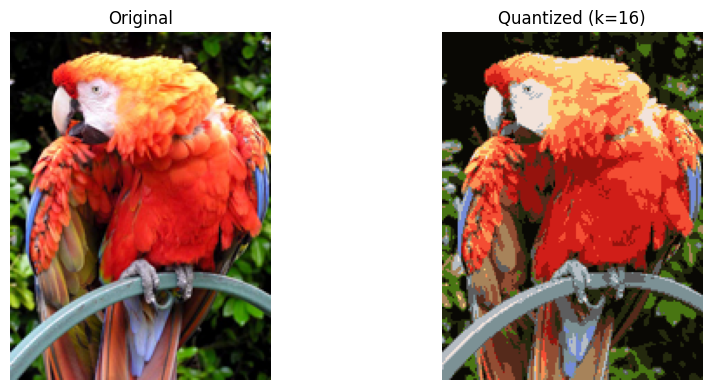

In [13]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 단계는 앞서 k-Means로 클러스터링된 정보를 바탕으로
# 원본 이미지의 각 픽셀을 해당 클러스터의 중심색(palette)으로 치환하여
# 새로운 양자화 이미지를 복원하고 시각화하는 과정임.
# 최종적으로 원본 이미지와 양자화 이미지를 나란히 비교할 수 있도록 시각화함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 각 픽셀에 해당하는 클러스터 중심색으로 새 이미지를 구성
# 2단계: 정규화된 색상값을 다시 0~255 범위로 변환하고 정수형으로 변환
# 3단계: PIL을 이용해 이미지를 저장
# 4단계: 원본 이미지와 양자화 이미지를 나란히 시각화
# ------------------------------------------------------------

quant_img = (palette[labels].reshape(h, w, 3) * 255).astype(np.uint8)  
# 각 픽셀의 클러스터 ID(labels)를 인덱스로 사용해 해당 중심색(palette)으로 매핑함
# 그 결과는 (H x W x 3) 크기의 새로운 이미지 배열이 됨
# 현재 palette는 정규화된 값(0~1)이므로 255를 곱해 원래 RGB 범위로 복원함
# uint8 타입으로 변환하여 이미지 저장 및 시각화에 적합한 형태로 만듦

Image.fromarray(quant_img).save('output_k16.jpg')  
# NumPy 배열 형태의 양자화된 이미지를 PIL 이미지로 변환한 후
# 'output_k16.jpg'라는 이름으로 저장함
# 이후 분석, 리포트, 전처리 데이터 등으로 활용 가능함

fig, ax = plt.subplots(1, 2, figsize=(10, 4))  
# 1행 2열의 subplot을 생성하여 원본 이미지와 양자화 이미지를 나란히 비교할 준비를 함
# 전체 출력 크기는 가로 10인치, 세로 4인치로 설정함

ax[0].imshow(img_np)  
# 첫 번째 subplot에 원본 이미지를 표시함

ax[0].set_title('Original')  
# 첫 번째 subplot의 제목을 'Original'로 지정함

ax[0].axis('off')  
# 첫 번째 subplot에서 x축과 y축 눈금 및 틀을 제거함

ax[1].imshow(quant_img)  
# 두 번째 subplot에 양자화된 이미지를 표시함

ax[1].set_title(f'Quantized (k={k})')  
# 두 번째 subplot의 제목을 'Quantized (k=16)'으로 설정하여 색상 수를 명시함

ax[1].axis('off')  
# 두 번째 subplot에서도 축을 제거하여 시각적 단순성을 확보함

plt.tight_layout()  
# 두 subplot 간 간격을 자동 조절하여 시각적으로 겹치지 않도록 정렬함


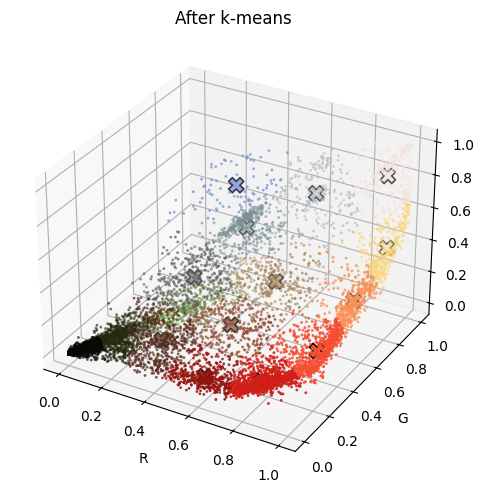

In [14]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 단계는 k-means 클러스터링 이후 각 픽셀이 어떤 클러스터에 속했는지를 기반으로
# RGB 색상 공간 상에서 군집된 결과를 시각화하는 과정임.
# 각 픽셀은 클러스터의 중심 색상으로 색칠되고,
# 클러스터 중심들은 별도의 마커(X)로 강조되어 시각적으로 구분됨.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 이전에 시각화용으로 샘플링했던 픽셀들의 클러스터 라벨 추출
# 2단계: 3D RGB 산점도 구성 및 픽셀 색상 재도색 (클러스터 중심 색상으로)
# 3단계: 클러스터 중심(palette)을 별도 마커로 시각화
# 4단계: 축 라벨 및 제목 설정, 레이아웃 정리
# ------------------------------------------------------------

labs = labels[idx]  
# 무작위로 샘플링한 픽셀 인덱스에 해당하는 클러스터 라벨을 추출함
# 이 샘플은 RGB 산점도에 색상 재할당 후 표시될 점들임

fig = plt.figure(figsize=(12, 5))  
# 가로 12인치, 세로 5인치 크기의 새 figure 생성
# 3D 시각화를 위한 충분한 공간 확보 목적임

ax2 = fig.add_subplot(1, 1, 1, projection='3d')  
# 1행 1열 중 첫 번째 subplot을 3D 축으로 설정함
# RGB 공간에 분포된 색상 클러스터 구조를 시각적으로 표현하기 위함임

ax2.scatter(Xs[:, 0], Xs[:, 1], Xs[:, 2], c=palette[labs], s=4, edgecolor='none')  
# 샘플링한 픽셀들의 RGB 값을 x, y, z 축으로 하여 산점도 생성
# 각 점의 색상은 해당 픽셀이 속한 클러스터의 중심 색상으로 설정함
# 점 크기는 작게(s=4), 테두리는 없음(edgecolor='none')으로 설정함
# 클러스터링 후 색상이 어떻게 정렬되었는지 시각적으로 보여줌

ax2.scatter(palette[:, 0], palette[:, 1], palette[:, 2],  
            c=palette, marker='X', s=120, edgecolor='k', linewidths=1.2, label='centroid')  
# 클러스터 중심 좌표를 큰 'X' 마커로 시각화함
# 각 중심은 고유 색상으로 표시되며, 외곽선은 검정색으로 강조함
# 마커 크기를 크게(s=120), 테두리를 두껍게 설정하여 일반 픽셀과 시각적으로 구분되게 함
# 클러스터 중심점이 색상 공간 내 어디에 분포해 있는지 보여주는 핵심 요소임

ax2.set_title('After k-means')  
# 그래프 제목을 설정하여 클러스터링 이후 시각화임을 명확히 표현함

ax2.set_xlabel('R')  
# x축 라벨을 'R'로 설정하여 빨간색 채널임을 명시함

ax2.set_ylabel('G')  
# y축 라벨을 'G'로 설정하여 초록색 채널임을 명시함

ax2.set_zlabel('B')  
# z축 라벨을 'B'로 설정하여 파란색 채널임을 명시함

plt.tight_layout()  
# 그래프 요소들이 겹치지 않도록 전체 레이아웃을 자동 조절함
